In [1]:
import pathlib

import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
from STX3KO_analyses.run_sig_fields_spatial_perm import filter_fields


ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice


plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig3_place_fields')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
with open('/home/mplitt/shuffle_pkls/dense_place_field_spatial_shuffle_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)
            

In [5]:
widths = shuff_results[ctrl_mice[0]][0]['fam']['field_widths']

In [8]:
(widths==1).sum()

np.int64(154)

In [9]:
sess = u.load_single_day(ctrl_mice[0], 0)
sess.trial_matrices['F_dff'].shape

{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


(139, 30, 1381)

# number of fields per cell 

In [7]:
df = {'cre': [], 'mouse': [], 'day': [], 'nov': [], 'n_fields': []}
for key, mice in zip(('ctrl', 'ko'),(ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(6):
            for nov in ( 'fam', 'nov'):

                rising_edges = shuff_results[mouse][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][day][nov]['falling_edges']

                width = falling_edges[:,1]-rising_edges[:,1]
                mask = (width>1) * (width<25) 
                n_fields = np.bincount(rising_edges[mask,0])
                

                # widths = shuff_resu
        
                n_fields = n_fields[n_fields>0]

                for n in n_fields:
                    df['cre'].append(key)
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['n_fields'].append(n)

df = pd.DataFrame.from_dict(df)

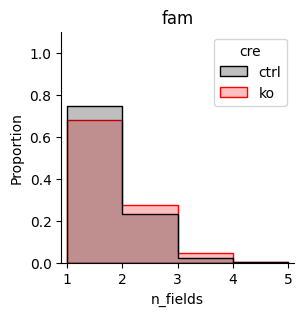

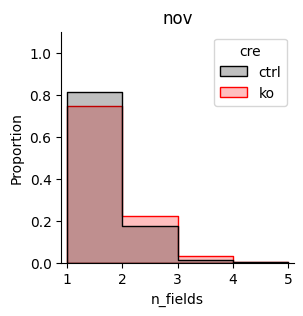

In [8]:
for nov in ('fam', 'nov'):

    fig,ax = plt.subplots(figsize=[3,3])
    sns.histplot(data=df.loc[df['nov']==nov], x='n_fields', hue='cre', cumulative=False, hue_order=('ctrl', 'ko'), palette=['black', 'red'],
                binwidth=1, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    ax.set_ylim([0,1.1])
    ax.set_xlim([.9,5.1])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)

    fig.savefig(figdir / f'fields_per_cell_hist_{nov}.pdf', bbox_inches='tight')


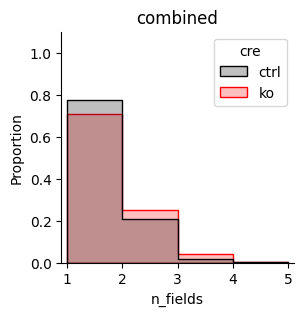

In [9]:


fig,ax = plt.subplots(figsize=[3,3])
sns.histplot(data=df, x='n_fields', hue='cre', cumulative=False, hue_order=('ctrl', 'ko'), palette=['black', 'red'],
            binwidth=1, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
ax.set_ylim([0,1.1])
ax.set_xlim([.9,5.1])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('combined')

fig.savefig(figdir / f'fields_per_cell_hist_combined.pdf', bbox_inches='tight')

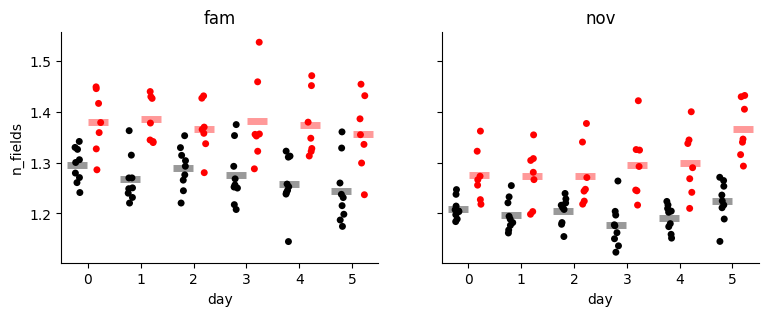

In [10]:
df_mu = df.groupby(['mouse','day','cre','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='n_fields',
                hue='cre', 
                hue_order=('ctrl', 'ko'), 
                palette=['black', 'red'],
                dodge=True,
                ax=ax[i],
                legend=False)
    


    sns.pointplot(data=df_mu.loc[df_mu['nov']==nov,:],
              x='day',
              y='n_fields',
              errorbar=None,
              hue='cre',
              hue_order=('ctrl', 'ko'), 
              palette=['black', 'red'],
              dodge = .4,
              ax=ax[i],
              linestyles="none",
              marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
              )
    ax[i].set_title(nov)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig( figdir / 'num_fields_per_day.pdf', bbox_inches='tight')


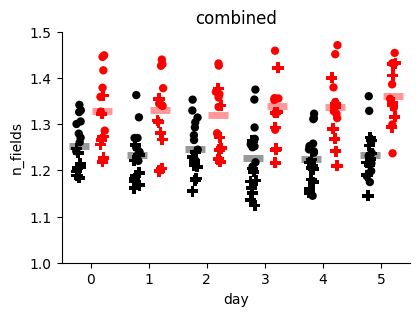

In [12]:
df_mu = df.groupby(['mouse','day','cre','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(figsize=[4.5,3], sharey = True)
sns.stripplot(data=df_mu.loc[df_mu['nov']=='fam',:],
            x='day',
            y='n_fields',
            hue='cre', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax, s=6,
            legend=False)

sns.stripplot(data=df_mu.loc[df_mu['nov']=='nov',:],
            x='day',
            y='n_fields',
            hue='cre', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            marker='P',
            alpha=1,
            dodge=True,
            ax=ax, s=8, 
            legend=False)



sns.pointplot(data=df_mu,
            x='day',
            y='n_fields',
            errorbar=None,
            hue='cre',
            dodge = .4,
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
ax.set_title('combined')
ax.set_ylim([1,1.5])


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig( figdir / 'num_fields_per_day_combined.pdf', bbox_inches='tight')


In [13]:
with open('/home/mplitt/shuffle_pkls/dense_n_fields_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']
    p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
    print(f"{stat} true coef = {true_coef}, p = {p} ")



n_fields true coef = 0.0811189396003333, p = 0.003321678321678322 
rank_n_fields true coef = 3989.0634357832523, p = 0.0034965034965034965 


In [14]:
mdl = model_shuff_results['rank_n_fields']['true_model']
mdl.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                       Mixed Linear Model Regression Results
====================================================================================
Model:                    MixedLM         Dependent Variable:         rank_n_fields 
No. Observations:         129861          Method:                     REML          
No. Groups:               16              Scale:                      790486814.7732
Min. group size:          2565            Log-Likelihood:             -1514419.1312 
Max. group size:          12680           Converged:                  Yes           
Mean group size:          8116.3                                                    
------------------------------------------------------------------------------------
                                 Coef.    Std.Err.    z    P>|z|   [0.025    0.975] 
------------------------------------------------------------------------------------
Intercept                       65881.018  708.257  93.019 0.000 64492.860 67269.177
cre[T.ko]                        3989.063 1081.993   3.687 0.000  1868.395  6109.732
day[T.1]                        -1469.433  465.234  -3.158 0.002 -2381.275  -557.592
day[T.2]                         -258.370  459.485  -0.562 0.574 -1158.944   642.205
day[T.3]                        -1048.553  463.160  -2.264 0.024 -1956.330  -140.777
day[T.4]                        -2017.422  468.504  -4.306 0.000 -2935.674 -1099.170
day[T.5]                        -2688.312  470.787  -5.710 0.000 -3611.036 -1765.587
nov[T.nov]                      -5204.960  501.408 -10.381 0.000 -6187.701 -4222.218
cre[T.ko]:day[T.1]               1728.922  717.094   2.411 0.016   323.444  3134.400
cre[T.ko]:day[T.2]               -300.048  710.895  -0.422 0.673 -1693.377  1093.282
cre[T.ko]:day[T.3]               1563.435  719.083   2.174 0.030   154.057  2972.812
cre[T.ko]:day[T.4]               1587.431  738.720   2.149 0.032   139.565  3035.297
cre[T.ko]:day[T.5]               1622.746  734.349   2.210 0.027   183.448  3062.043
cre[T.ko]:nov[T.nov]             -866.463  791.156  -1.095 0.273 -2417.100   684.173
day[T.1]:nov[T.nov]               979.810  727.522   1.347 0.178  -446.107  2405.728
day[T.2]:nov[T.nov]               170.797  713.550   0.239 0.811 -1227.735  1569.329
day[T.3]:nov[T.nov]              -810.063  717.960  -1.128 0.259 -2217.238   597.112
day[T.4]:nov[T.nov]              1214.808  722.757   1.681 0.093  -201.770  2631.385
day[T.5]:nov[T.nov]              4059.073  696.683   5.826 0.000  2693.599  5424.546
cre[T.ko]:day[T.1]:nov[T.nov]   -1081.869 1116.442  -0.969 0.333 -3270.055  1106.318
cre[T.ko]:day[T.2]:nov[T.nov]     304.382 1101.528   0.276 0.782 -1854.573  2463.337
cre[T.ko]:day[T.3]:nov[T.nov]    1192.506 1112.327   1.072 0.284  -987.615  3372.627
cre[T.ko]:day[T.4]:nov[T.nov]     144.761 1146.811   0.126 0.900 -2102.947  2392.469
cre[T.ko]:day[T.5]:nov[T.nov]    2616.120 1089.955   2.400 0.016   479.847  4752.393
Group Var                     3580599.105   49.864                                  
====================================================================================

"""

In [15]:
mdl.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                               chi2                  P>chi2  df constraint
Intercept     [[8652.442362944925]]                     0.0              1
cre           [[13.59228917113609]]  0.00022711650141329047              1
day          [[47.477758977096244]]   4.539752058164284e-09              5
nov           [[107.7586690095219]]   3.035816523734238e-25              1
cre:day      [[16.570416870929513]]    0.005390862371806901              5
cre:nov       [[1.199434584527438]]      0.2734347159115912              1
day:nov      [[59.221123147254445]]   1.760512965597814e-11              5
cre:day:nov  [[13.381429662275496]]     0.02005486400880843              5

# field width 

In [16]:
df = {'cre': [], 'mouse': [], 'day': [], 'nov': [], 'width': []}
for key, mice in zip(('ctrl', 'ko'),(ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(6):
            for nov in ('fam','nov'):
                rising_edges = shuff_results[mouse][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][day][nov]['falling_edges']
                widths = shuff_results[mouse][day][nov]['field_widths']
                
                mask = (widths>1) * (widths<25) * (rising_edges[:,1]>0) * (falling_edges[:,1]<29)
                widths = widths[mask]
                

                for w in widths:
                    df['cre'].append(key)
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
             
                    df['width'].append(w*10)
df = pd.DataFrame(df)

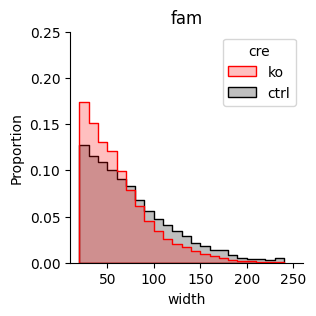

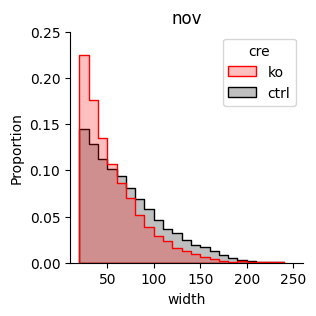

In [17]:
for nov in ('fam', 'nov'):
    fig,ax = plt.subplots(figsize=[3,3])
    sns.histplot(data=df.loc[df['nov']==nov,:], 
                x='width', 
                hue='cre', 
                cumulative=False, 
                hue_order=('ko', 'ctrl'), 
                palette=['red', 'black'],
                binwidth=10, 
                fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    # ax.set_ylim([0,1.1])
    ax.set_xlim([10,260])
    ax.set_ylim([0,.25])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)
    fig.savefig(figdir / f'field_widths_hist_{nov}.pdf', bbox_inches='tight')


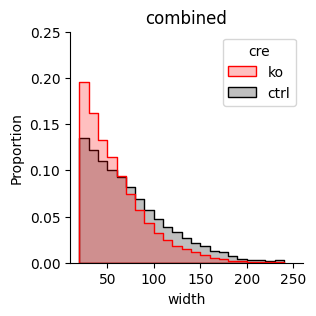

In [18]:

fig,ax = plt.subplots(figsize=[3,3])
sns.histplot(data=df, 
            x='width', 
            hue='cre', 
            cumulative=False, 
            hue_order=('ko', 'ctrl'), 
            palette=['red', 'black'],
            binwidth=10, 
            fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
# ax.set_ylim([0,1.1])
ax.set_xlim([10,260])
ax.set_ylim([0,.25])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('combined')
fig.savefig(figdir / f'field_widths_hist_combined.pdf', bbox_inches='tight')


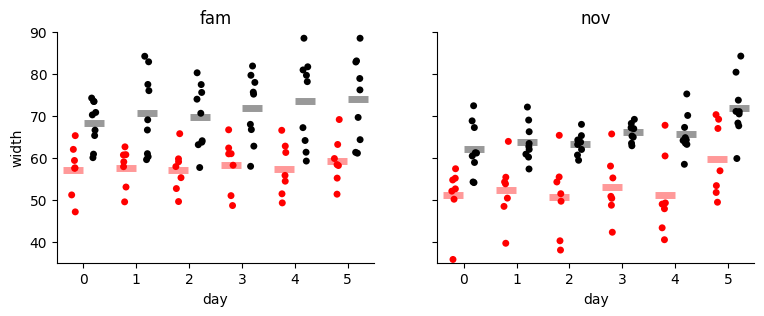

In [19]:
df_mu = df.groupby(['mouse','day','cre','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey=True)
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='width',
                hue='cre', 
                hue_order=('ko', 'ctrl'), 
                palette=['red', 'black'],
                dodge=True,
                ax=ax[i],
                legend=False)
    
    sns.pointplot(data=df_mu.loc[df_mu['nov']==nov,:],
              x='day',
              y='width',
              errorbar=None,
              hue='cre',
              hue_order = ['ko', 'ctrl'],
              dodge = .4,
              palette = ['red','black'],
              ax=ax[i],
              linestyles="none",
              marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
              )
    ax[i].set_title(nov)
    ax[i].set_ylim([35,90])
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig( figdir / 'field_widths_per_day.pdf', bbox_inches='tight')

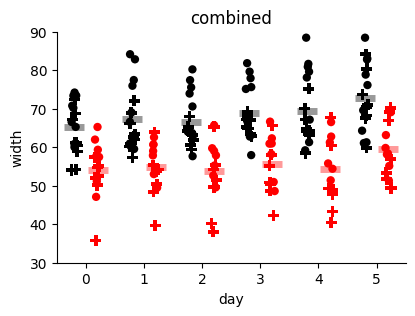

In [26]:
df_mu = df.groupby(['mouse','day','cre','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(figsize=[4.5,3], sharey=True)

sns.stripplot(data=df_mu.loc[df_mu['nov']=='fam',:],
            x='day',
            y='width',
            hue='cre', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax, s=6,
            legend=False)

sns.stripplot(data=df_mu.loc[df_mu['nov']=='nov',:],
            x='day',
            y='width',
            hue='cre', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            marker='P', s=8,
            alpha=1., 
            dodge=True,
            ax=ax,
            legend=False)


sns.pointplot(data=df_mu,
            x='day',
            y='width',
            errorbar=None,
            hue='cre',
            dodge = .4,
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
ax.set_title('combined')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([30,90])

fig.savefig( figdir / 'field_widths_per_day_combined.pdf', bbox_inches='tight')

In [22]:
with open('/home/mplitt/shuffle_pkls/dense_width_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']
    p = (true_coef>shuff_coefs).sum()/float(shuff_coefs.shape[0])
    print(f"{stat} true coef = {true_coef}, p = {p} ")



width true coef = -11.260519336395545, p = 0.001486013986013986 
rank_width true coef = -7707.646501764529, p = 0.0006993006993006993 


In [23]:
mdl = model_shuff_results['rank_width']['true_model']
mdl.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Mixed Linear Model Regression Results
=====================================================================================
Model:                     MixedLM         Dependent Variable:         rank_width    
No. Observations:          99253           Method:                     REML          
No. Groups:                16              Scale:                      774796127.0317
Min. group size:           1980            Log-Likelihood:             -1156448.0287 
Max. group size:           12611           Converged:                  No            
Mean group size:           6203.3                                                    
-------------------------------------------------------------------------------------
                                 Coef.     Std.Err.   z    P>|z|   [0.025     0.975] 
-------------------------------------------------------------------------------------
Intercept                        54034.396 1376.427 39.257 0.000  51336.648 56732.144
cre[T.ko]                        -7707.647 2080.817 -3.704 0.000 -11785.973 -3629.320
day[T.1]                           930.391  540.070  1.723 0.085   -128.128  1988.909
day[T.2]                           344.049  534.490  0.644 0.520   -703.532  1391.631
day[T.3]                          1466.184  543.896  2.696 0.007    400.166  2532.201
day[T.4]                          2205.862  553.980  3.982 0.000   1120.082  3291.642
day[T.5]                          2819.224  556.963  5.062 0.000   1727.596  3910.852
nov[T.nov]                       -4417.096  568.289 -7.773 0.000  -5530.923 -3303.270
cre[T.ko]:day[T.1]                 328.584  791.296  0.415 0.678  -1222.328  1879.497
cre[T.ko]:day[T.2]                 812.673  788.103  1.031 0.302   -731.980  2357.326
cre[T.ko]:day[T.3]                 279.142  801.450  0.348 0.728  -1291.671  1849.955
cre[T.ko]:day[T.4]               -1771.992  821.388 -2.157 0.031  -3381.882  -162.102
cre[T.ko]:day[T.5]                -235.537  819.817 -0.287 0.774  -1842.350  1371.276
cre[T.ko]:nov[T.nov]             -1357.993  858.092 -1.583 0.114  -3039.823   323.837
day[T.1]:nov[T.nov]                369.186  835.917  0.442 0.659  -1269.182  2007.553
day[T.2]:nov[T.nov]               1337.358  819.868  1.631 0.103   -269.554  2944.270
day[T.3]:nov[T.nov]               1944.984  834.415  2.331 0.020    309.561  3580.407
day[T.4]:nov[T.nov]                942.428  842.726  1.118 0.263   -709.285  2594.141
day[T.5]:nov[T.nov]               4127.750  819.451  5.037 0.000   2521.656  5733.844
cre[T.ko]:day[T.1]:nov[T.nov]      462.058 1228.156  0.376 0.707  -1945.083  2869.200
cre[T.ko]:day[T.2]:nov[T.nov]    -2914.548 1211.901 -2.405 0.016  -5289.831  -539.266
cre[T.ko]:day[T.3]:nov[T.nov]    -1068.269 1233.547 -0.866 0.386  -3485.977  1349.439
cre[T.ko]:day[T.4]:nov[T.nov]    -1604.555 1265.793 -1.268 0.205  -4085.464   876.354
cre[T.ko]:day[T.5]:nov[T.nov]      287.671 1213.067  0.237 0.813  -2089.897  2665.239
Group Var                     15829701.479                                           
=====================================================================================

"""

In [24]:
mdl.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                               chi2                 P>chi2  df constraint
Intercept     [[1541.111690206364]]                    0.0              1
cre          [[13.720686540523532]]  0.0002121053252815535              1
day           [[37.25167472557716]]  5.332412046268091e-07              5
nov           [[60.41363373309942]]  7.687864288574474e-15              1
cre:day      [[11.192373429888844]]    0.04769641144954361              5
cre:nov       [[2.504534171368485]]    0.11351904700653227              1
day:nov      [[31.549314141515367]]  7.295678260861718e-06              5
cre:day:nov   [[11.48526048014041]]    0.04256378657087032              5